mean: -0.27259427394775404
power: 2254.396068012476


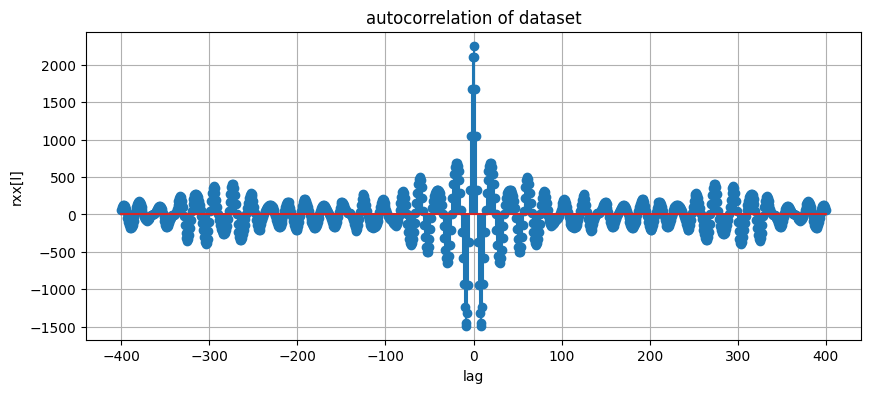

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags

x = np.loadtxt("dataset.dat")
N = len(x)

print("mean:", np.mean(x))
print("power:", np.mean(x**2))

x0 = x - np.mean(x)  #remove the mean from the signal
#correlate(x,y), we correlate the first signal with itself
rxx = correlate(x0,x0,mode="full") / N  #correlation gives a sum of products, dividing turn into average
#same as correlate(x,y), correlate the two function inputs.
lags = correlation_lags(N,N, mode="full")

#page 187, "meaning full measure of similarity for small lags -> 20%"
max_lag = 400
#keep only samples that are within the bounds of a given lag
mask = (lags >= -max_lag) & (lags <= max_lag)

plt.figure(figsize=(10,4))
plt.stem(lags[mask], rxx[mask])
plt.xlabel("lag")
plt.ylabel("rxx[l]")
plt.title("autocorrelation of dataset")
plt.grid(True)
plt.show()



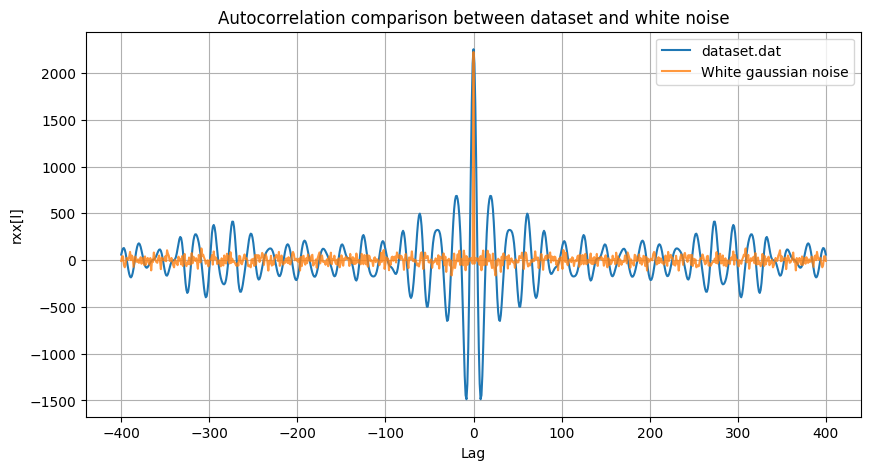

In [30]:
P = np.mean(x0**2)
w = np.random.normal(
    loc=0,
    scale=np.sqrt(P),
    size=N
)

rww = correlate(w, w, mode="full") / N
plt.figure(figsize=(10, 5))

plt.plot(
    lags[mask],
    rxx[mask],
    label="dataset.dat"
)

plt.plot(
    lags[mask],
    rww[mask],
    label="White gaussian noise",
    alpha=0.8
)

plt.xlabel("Lag")
plt.ylabel("rxx[l]")
plt.title("Autocorrelation comparison between dataset and white noise")
plt.grid()
plt.legend()
plt.show()
